<a href="https://colab.research.google.com/github/nehasingh913833-gif/basic-ML/blob/main/2DE_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install nilearn
import numpy as np
import tensorflow as tf
from nilearn.datasets import fetch_development_fmri, fetch_atlas_msdl
from nilearn.maskers import NiftiMapsMasker
from nilearn.connectome import ConnectivityMeasure
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

import numpy as np
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score
)
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from nilearn import plotting
import matplotlib.pyplot as plt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 46.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 5.3 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


Fetching Atlas and fMRI data...


[fetch_atlas_msdl] Added README.md to /root/nilearn_data

[fetch_atlas_msdl] Dataset created in /root/nilearn_data/msdl_atlas

[fetch_atlas_msdl] Downloading data from https://team.inria.fr/parietal/files/2015/01/MSDL_rois.zip ...

[fetch_atlas_msdl]  ...done. (1 seconds, 0 min)

...

[fetch_development_fmri] Downloading data from https://osf.io/download/5cb46e5c353c5800199ac79f/ ...

[fetch_development_fmri]  ...done. (3 seconds, 0 min)

Extracting time-series signals...


/tmp/ipykernel_3004/508815122.py:22: UserWarning: memory_level is currently set to 0 but a Memory object has been provided. Setting memory_level to 1.
  time_series = masker.fit_transform(func_file)
/tmp/ipykernel_3004/508815122.py:22: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  time_series = masker.fit_transform(func_file)
/tmp/ipykernel_3004/508815122.py:22: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  time_series = masker.fit_transform(func_file)
/tmp/ipykernel_3004/508815122.py:22: FutureWarning: boolean values for 'standardize' will be deprecated in nilearn 0.15.0.
Use 'zscore_sample' instead of 'True' or use 'None' instead of 'False'.
  time_series = masker.fit_transform(func_file)
/tmp/ipykernel_3004/508815122.py:22: FutureWarning: boolean values for '

Computing Parametric Pearson Correlation Matrices...
Visualizing Time Series and Connectivity Matrix for Subject 1...


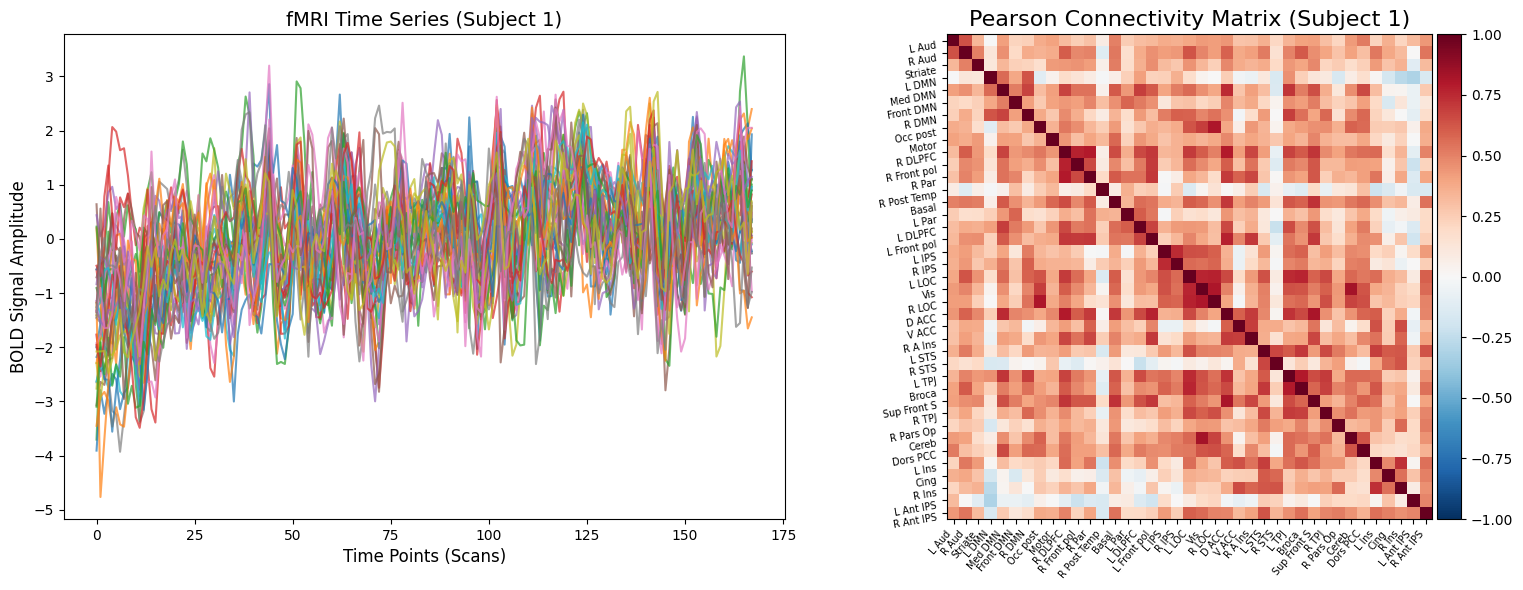

Building and Training the 2D CNN...
Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 246ms/step - accuracy: 0.5714 - loss: 0.6655 - val_accuracy: 1.0000 - val_loss: 0.2516
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.7619 - loss: 0.5415 - val_accuracy: 1.0000 - val_loss: 0.1377
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.7619 - loss: 0.4308 - val_accuracy: 1.0000 - val_loss: 0.0725
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.7619 - loss: 0.4213 - val_accuracy: 1.0000 - val_loss: 0.0432
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - accuracy: 0.7143 - loss: 0.3960 - val_accuracy: 1.0000 - val_loss: 0.0226
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.7619 - loss: 0.3240 - val_accuracy: 1.0000 - val_loss: 0.0401
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9524 - loss: 0.2850 - val_accuracy: 1.0000 - val_loss: 0.0200
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.8095 - loss: 0.2712 - val_accuracy: 1.0000 - val_loss: 0.0046
Epoch 9/20

In [ ]:



# 1. ATLAS & BRAIN PARCELLATION

print("Fetching Atlas and fMRI data...")
# Load the MSDL atlas (probabilistic parcellation)
atlas = fetch_atlas_msdl()
atlas_filename = atlas.maps

# Load fMRI data (using the development dataset as the source)
fmri_dataset = fetch_development_fmri(n_subjects=30) # Adjust n_subjects as needed
fmri_filenames = fmri_dataset.func
phenotypic = fmri_dataset.phenotypic


# 2. ROI EXTRACTION & TIME SERIES GENERATION

print("Extracting time-series signals...")
# Map the fMRI data to the Atlas to get Region of Interest (ROI) signals
masker = NiftiMapsMasker(maps_img=atlas_filename, standardize=True, memory='nilearn_cache', verbose=0)

time_series_list = []
for func_file in fmri_filenames:
    time_series = masker.fit_transform(func_file)
    time_series_list.append(time_series)


# 3. PARAMETRIC PEARSON & MATRIX FORM

print("Computing Parametric Pearson Correlation Matrices...")
# Compute Pearson correlation.
# vectorize=False keeps it in 2D Matrix Form (N x N) for the 2D CNN
correlation_measure = ConnectivityMeasure(kind='correlation', vectorize=False)
connectivity_matrices = correlation_measure.fit_transform(time_series_list)

# The shape is (samples, ROIs, ROIs).
# We add a channel dimension (1) at the end because Conv2D expects (samples, height, width, channels)
X = np.expand_dims(connectivity_matrices, axis=-1)

# Prepare Labels
y = phenotypic['Child_Adult']
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)



# 3.5 VISUALIZING THE DATA (EDA)

print("Visualizing Time Series and Connectivity Matrix for Subject 1...")

# Select the first subject in your dataset
subject_idx = 0
sample_time_series = time_series_list[subject_idx]
sample_matrix = connectivity_matrices[subject_idx]

# Create the figure and two axes
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: The ROI Time Series ---
axes[0].plot(sample_time_series, alpha=0.7)
axes[0].set_title(f'fMRI Time Series (Subject {subject_idx + 1})', fontsize=14)
axes[0].set_xlabel('Time Points (Scans)', fontsize=12)
axes[0].set_ylabel('BOLD Signal Amplitude', fontsize=12)

# --- Plot 2: The Pearson Connectivity Matrix ---
plotting.plot_matrix(
    sample_matrix,
    labels=atlas.labels,
    axes=axes[1],       # KEEP THIS
    # figure=fig,       <-- REMOVED THIS LINE
    vmax=1.0, vmin=-1.0,
    colorbar=True,
    title=f'Pearson Connectivity Matrix (Subject {subject_idx + 1})'
)

plt.tight_layout()
plt.show()

# 4. CLASSIFICATION [2D CNN]

print("Building and Training the 2D CNN...")
input_shape = (X_train.shape[1], X_train.shape[2], 1)

model = Sequential([
    # First Convolutional Block
    Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
    MaxPooling2D(pool_size=(2, 2)),

    # Second Convolutional Block
    Conv2D(64, kernel_size=(3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # Flatten the 2D matrices into 1D for the Dense classifier
    Flatten(),

    # Fully Connected Layers
    Dense(128, activation='relu'),
    Dropout(0.5), # Helps prevent overfitting
    Dense(1, activation='sigmoid') # Binary classification (e.g., Child vs Adult)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=20, batch_size=8, validation_split=0.1, verbose=1)


# 5. EVALUATION & METRICS

print("\nEvaluating Model...")
y_pred_prob = model.predict(X_test)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print(f"Actual Classes    : {np.unique(y_test)}")
print(f"Predicted Classes : {np.unique(y_pred)}")

# Print Metrics
auc_score = roc_auc_score(y_test, y_pred_prob)
print(f"AUC Score         : {auc_score:.4f}")
print("Confusion Matrix  :")
print(confusion_matrix(y_test, y_pred))

In [ ]:

#  CROSS-VALIDATION & EVALUATION



print("Starting 5-Fold Cross Validation...")


def create_model(input_shape):
    model = Sequential([
        Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=input_shape),
        MaxPooling2D(pool_size=(2, 2)),
        Conv2D(64, kernel_size=(3, 3), activation='relu'),
        MaxPooling2D(pool_size=(2, 2)),
        Flatten(),
        Dense(128, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# Cross-Validation
n_splits = 5
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# Lists to store metrics for each fold
acc_scores, prec_scores, sens_scores, spec_scores, f1_scores, auc_scores = [], [], [], [], [], []

input_shape = (X.shape[1], X.shape[2], 1)
fold_no = 1

# Loop through each fold
for train_index, test_index in skf.split(X, y_encoded):
    print(f"\n--- Training Fold {fold_no} ---")

    # Split data for this fold
    X_train_fold, X_test_fold = X[train_index], X[test_index]
    y_train_fold, y_test_fold = y_encoded[train_index], y_encoded[test_index]

    # Create and train a fresh model
    model = create_model(input_shape)
    model.fit(X_train_fold, y_train_fold, epochs=20, batch_size=8, verbose=0) # verbose=0 to hide epoch progress bars

    # Predict on the test fold
    y_pred_prob = model.predict(X_test_fold, verbose=0)
    y_pred = (y_pred_prob > 0.5).astype(int).flatten()

    # Calculate metrics for this fold
    acc_scores.append(accuracy_score(y_test_fold, y_pred))
    prec_scores.append(precision_score(y_test_fold, y_pred, zero_division=0))
    sens_scores.append(recall_score(y_test_fold, y_pred, zero_division=0)) # Sensitivity
    f1_scores.append(f1_score(y_test_fold, y_pred, zero_division=0))

    # Handle Specificity
    cm = confusion_matrix(y_test_fold, y_pred)
    if cm.size == 4: # Normal 2x2 matrix
        tn, fp, fn, tp = cm.ravel()
        spec_scores.append(tn / (tn + fp) if (tn + fp) > 0 else 0)
    else:
        spec_scores.append(0) # Failsafe if a fold only has one class predicted

    # Handle AUC
    try:
        auc_scores.append(roc_auc_score(y_test_fold, y_pred_prob))
    except ValueError:
        pass # Failsafe if a fold is missing a class

    fold_no += 1


# FINAL AGGREGATED RESULTS

print("\n" + "="*30)
print("FINAL CROSS-VALIDATION RESULTS")
print("="*30)

# Print in the exact requested format: Mean ± Standard Deviation
print(f"Accuracy    : {np.mean(acc_scores):.4f} ± {np.std(acc_scores):.4f}")
print(f"Precision   : {np.mean(prec_scores):.4f} ± {np.std(prec_scores):.4f}")
print(f"Sensitivity : {np.mean(sens_scores):.4f} ± {np.std(sens_scores):.4f}")
print(f"Specificity : {np.mean(spec_scores):.4f} ± {np.std(spec_scores):.4f}")
print(f"F1 Score    : {np.mean(f1_scores):.4f} ± {np.std(f1_scores):.4f}")
print(f"AUC Score   : {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

Starting 5-Fold Cross Validation...

--- Training Fold 1 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Fold 2 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Fold 3 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Fold 4 ---


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



--- Training Fold 5 ---



FINAL CROSS-VALIDATION RESULTS
Accuracy    : 0.7333 ± 0.0816
Precision   : 0.8267 ± 0.1062
Sensitivity : 0.8800 ± 0.1600
Specificity : 0.2000 ± 0.4000
F1 Score    : 0.8336 ± 0.0643
AUC Score   : 0.7600 ± 0.2332


NameError: name 'all_histories' is not defined

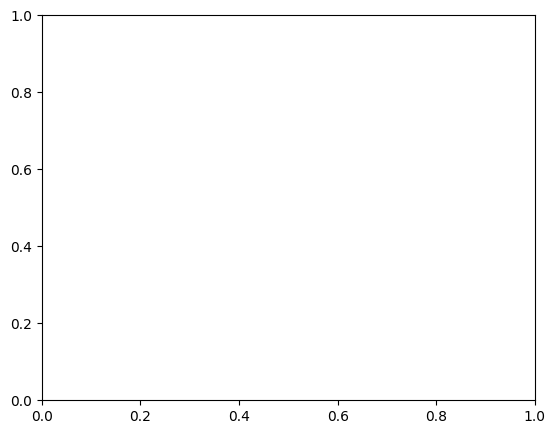

In [ ]:

# PLOTTING ACCURACY & LOSS ACROSS FOLDS

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))

# Plot 1: Accuracy
plt.subplot(1, 2, 1)
for i, history_dict in enumerate(all_histories):
    plt.plot(history_dict['accuracy'], label=f'Fold {i+1} Train', linestyle='-')
    if 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_accuracy'], label=f'Fold {i+1} Val', linestyle='--')

plt.title('Model Accuracy across Folds', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='lower right', fontsize=8, ncol=2)
plt.grid(alpha=0.3)

# Plot 2: Loss
plt.subplot(1, 2, 2)
for i, history_dict in enumerate(all_histories):
    plt.plot(history_dict['loss'], label=f'Fold {i+1} Train', linestyle='-')
    if 'val_loss' in history_dict:
        plt.plot(history_dict['val_loss'], label=f'Fold {i+1} Val', linestyle='--')

plt.title('Model Loss across Folds', fontsize=14)
plt.ylabel('Loss', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right', fontsize=8, ncol=2)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:

# PLOTTING ACCURACY VS. LOSS

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))

for i, history_dict in enumerate(all_histories):
    # Plot Training trajectory (Solid line with dots)
    plt.plot(history_dict['loss'], history_dict['accuracy'],
             label=f'Fold {i+1} Train', linestyle='-', marker='o', markersize=4, alpha=0.7)

    # Plot Validation trajectory (Dashed line with x's)
    if 'val_loss' in history_dict and 'val_accuracy' in history_dict:
        plt.plot(history_dict['val_loss'], history_dict['val_accuracy'],
                 label=f'Fold {i+1} Val', linestyle='--', marker='x', markersize=5, alpha=0.7)

plt.title('Model Trajectory: Accuracy vs. Loss (Across Epochs)', fontsize=14)
plt.xlabel('Loss (Lower is Better)', fontsize=12)
plt.ylabel('Accuracy (Higher is Better)', fontsize=12)

# Invert X-axis so the "best" outcome (low loss, high accuracy) is in the top right corner
plt.gca().invert_xaxis()

plt.legend(loc='lower left', fontsize=9, ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()